In [1]:
import ee

# 1. Credentials from your newly created service account
service_account = 'gee-python-bot@ee-mishrapriyanshu1505.iam.gserviceaccount.com'
key_file_path = 'gee_key.json' 

# 2. Authenticate directly via the cryptographic key
credentials = ee.ServiceAccountCredentials(service_account, key_file_path)

# 3. Initialize Earth Engine using your active project ID
try:
    ee.Initialize(credentials, project='ee-mishrapriyanshu1505')
    print("Connection successful! Authenticated perfectly via Service Account.")
except Exception as e:
    print(f"Initialization failed: {e}")


c:\Users\capaw\anaconda3\envs\river_morph\lib\site-packages\google\api_core\_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Connection successful! Authenticated perfectly via Service Account.


c:\Users\capaw\anaconda3\envs\river_morph\lib\site-packages\ee\deprecation.py:140: UserWarning: Unable to initialize deprecated assets: [ASN1: NOT_ENOUGH_DATA] not enough data (_ssl.c:4040)
  warnings.warn(f'Unable to initialize deprecated assets: {e}')


In [2]:
import ee
import geemap

# 1. Create an interactive map centered on the Brahmaputra (Assam)
Map = geemap.Map(center=[26.8, 93.8], zoom=10)

# 2. Define our Area of Interest (AOI) using a bounding box
aoi = ee.Geometry.Rectangle([93.4, 26.6, 94.2, 27.1])

# 3. Fetch Sentinel-2 Satellite Imagery
# Filtering for post-monsoon/winter dates to avoid cloud cover
dataset = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(aoi)
           .filterDate('2023-11-01', '2024-02-28')
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)))

# Create a clean, median composite image from the collection
image = dataset.median().clip(aoi)

# 4. Calculate NDWI (Green - NIR) / (Green + NIR)
# In Sentinel-2: Band 3 is Green, Band 8 is NIR
ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')

# 5. Create the Water Mask (NDWI > 0 usually indicates water)
water_mask = ndwi.gt(0)

# 6. Add the layers to our interactive map
# Add the true-color satellite image as a background
vis_params = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}
Map.addLayer(image, vis_params, 'True Color (Sentinel-2)')

# Add the water mask on top (using selfMask so the 0 values/land become transparent)
Map.addLayer(water_mask.selfMask(), {'palette': ['blue']}, 'Extracted Water Mask')

# Display the map in the notebook
Map

EEException: Permission 'earthengine.maps.create' denied on resource 'projects/ee-mishrapriyanshu1505' (or it may not exist).

In [ ]:
# 1. Clean the Mask: Remove small isolated water bodies (noise/ponds)
# We only keep connected water bodies larger than 100 pixels (~1 hectare)
pixel_count = water_mask.connectedPixelCount(100)
clean_water_mask = water_mask.updateMask(pixel_count.gte(100))

# 2. Calculate Total Water Area (Morphological Parameter 1)
# Multiply the clean mask (1s) by the physical area of each pixel on the ground
water_area_img = clean_water_mask.multiply(ee.Image.pixelArea())

# Sum up all the pixel areas within our Area of Interest (AOI)
area_stats = water_area_img.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi,
    scale=10,          # Sentinel-2 resolution is 10 meters
    maxPixels=1e10
)

# 3. Extract the number and convert from square meters to square kilometers
# The .getInfo() command pulls the calculation from Google's servers back to your local Python environment
area_sq_m = area_stats.get('NDWI').getInfo() 
area_sq_km = area_sq_m / 1e6

print("--- Morphological Analysis Results ---")
print(f"Total Water Surface Area: {area_sq_km:.2f} sq km")

# Optional: Update the map to show the cleaned mask instead of the noisy one
Map.addLayer(clean_water_mask.selfMask(), {'palette': ['cyan']}, 'Cleaned Water Mask')

--- Morphological Analysis Results ---
Total Water Surface Area: 222.75 sq km


In [ ]:
# The approximate length of the river reach inside our specific AOI bounding box
REACH_LENGTH_KM = 80 

def extract_river_morphology(year):
    """
    Automates the extraction of water area and average width for a given winter season.
    """
    start_date = f'{year}-11-01'
    end_date = f'{year+1}-02-28' 
    
    print(f"Processing imagery for {year}-{year+1} winter season...")
    
    dataset = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
               .filterBounds(aoi)
               .filterDate(start_date, end_date)
               .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)))
    
    image = dataset.median().clip(aoi)
    
    # FIX: Added .rename('NDWI') so the resulting dictionary knows what key to use
    ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')
    water_mask = ndwi.gt(0)
    clean_water_mask = water_mask.updateMask(water_mask.connectedPixelCount(100).gte(100))
    
    water_area_img = clean_water_mask.multiply(ee.Image.pixelArea())
    area_stats = water_area_img.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=10,
        maxPixels=1e10
    )
    
    # FIX: Explicitly looking for the uppercase 'NDWI' key
    area_sq_km = area_stats.get('NDWI').getInfo() / 1e6
    avg_width_meters = (area_sq_km / REACH_LENGTH_KM) * 1000
    
    print(f"Results for {year}:")
    print(f" - Total Water Area: {area_sq_km:.2f} sq km")
    print(f" - Average Channel Width: {avg_width_meters:.2f} meters\n")
    
    return clean_water_mask

# Rerun the extraction for our two comparison years
mask_2019 = extract_river_morphology(2019)
mask_2023 = extract_river_morphology(2023)

Processing imagery for 2019-2020 winter season...
Results for 2019:
 - Total Water Area: 248.75 sq km
 - Average Channel Width: 3109.34 meters

Processing imagery for 2023-2024 winter season...
Results for 2023:
 - Total Water Area: 222.75 sq km
 - Average Channel Width: 2784.38 meters



In [ ]:
# 1. Standardize masks: Set water to 1 and land to 0
w19 = mask_2019.unmask(0)
w23 = mask_2023.unmask(0)

# 2. Map Algebra: Subtract older year from newer year
migration = w23.subtract(w19)

# 3. Isolate the morphological changes
# .selfMask() makes the non-relevant areas transparent so we can layer them cleanly
erosion = migration.eq(1).selfMask()    # New water = red
accretion = migration.eq(-1).selfMask() # New land = green
stable = w19.And(w23).selfMask()        # Unchanged water = blue

# 4. Visualize Problem 2 Results
Map2 = geemap.Map(center=[26.8, 93.8], zoom=10)

Map2.addLayer(stable, {'palette': ['blue']}, 'Stable River Channel')
Map2.addLayer(accretion, {'palette': ['green']}, 'Accretion (Sandbar Deposition)')
Map2.addLayer(erosion, {'palette': ['red']}, 'Erosion (Bank Collapse)')

Map2

Map(center=[26.8, 93.8], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

--- Scour Depth Estimation Table ---
        Morphological Zone  Lacey Max Scour (m)  Blench Max Scour (m)
   Straight Reach (Stable)                 8.73                  7.56
             Moderate Bend                10.31                  8.93
Severe Bend (Erosion Zone)                13.75                 11.91




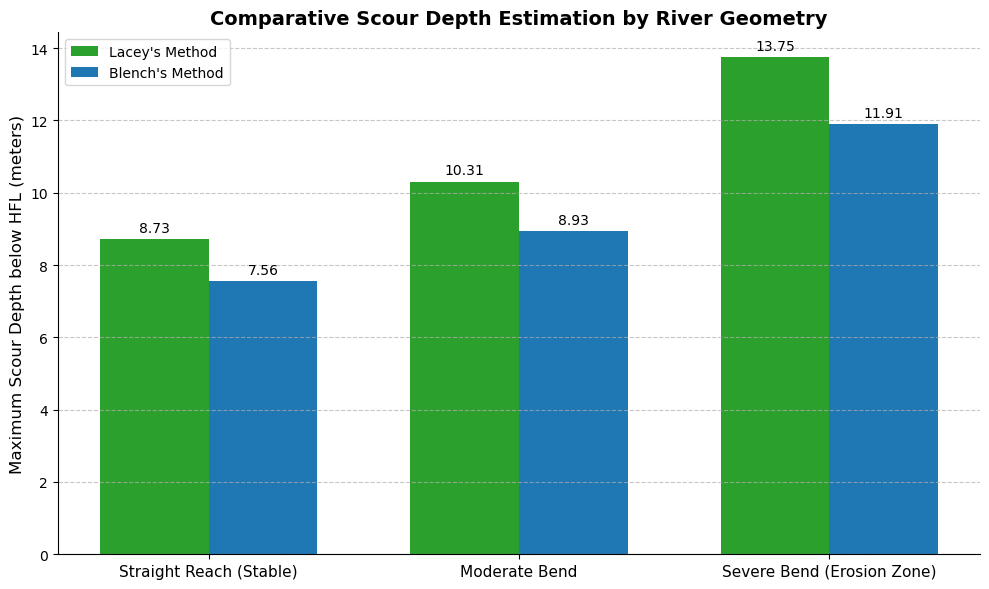

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Hydraulic Parameters (Integrating Problem 1 & 2 Data)
Q = 30000       # Design Discharge in m^3/s 
W = 2784        # Average Channel Width in meters (From 2023 satellite analysis)
d50 = 0.25      # Mean particle size in mm (Fine/medium sand)

# Discharge per unit width
q = Q / W

# 2. Lacey's Method Calculation
f = 1.76 * np.sqrt(d50)
R_lacey = 1.35 * (q**2 / f)**(1/3)

# 3. Blench's Method Calculation
F_b = 1.9 * np.sqrt(d50)
R_blench = 1.2 * (q**2 / F_b)**(1/3)

# 4. Critical Evaluation: Applying Multipliers for Morphological Zones
# Standard engineering practice dictates multiplying normal scour by a factor based on river geometry
factors = {
    'Straight Reach (Stable)': 1.27,
    'Moderate Bend': 1.50,
    'Severe Bend (Erosion Zone)': 2.00
}

# Compile the comparison data
results = []
for zone, factor in factors.items():
    results.append({
        'Morphological Zone': zone,
        'Lacey Max Scour (m)': round(R_lacey * factor, 2),
        'Blench Max Scour (m)': round(R_blench * factor, 2)
    })

df_scour = pd.DataFrame(results)

print("--- Scour Depth Estimation Table ---")
print(df_scour.to_string(index=False))
print("\n")

# 5. Visualization for the Submission PPT
x = np.arange(len(df_scour['Morphological Zone']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, df_scour['Lacey Max Scour (m)'], width, label="Lacey's Method", color='#2ca02c')
rects2 = ax.bar(x + width/2, df_scour['Blench Max Scour (m)'], width, label="Blench's Method", color='#1f77b4')

# Formatting for a clean, professional look
ax.set_ylabel('Maximum Scour Depth below HFL (meters)', fontsize=12)
ax.set_title('Comparative Scour Depth Estimation by River Geometry', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_scour['Morphological Zone'], fontsize=11)
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact value labels on top of the bars
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

# Remove top and right spines for a cleaner aesthetic
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()